<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/senior/wordcloud_naver_blog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontcon

In [20]:
import pandas as pd

df = pd.read_csv('blogs.csv')
df

,Unnamed: 0,title,contents,date
0,0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",​ 실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할...,2026. 2. 24. 15:46
1,1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 2~3시간이면 충분해! '등·하원 도우미' 스마트폰만 있으면 취업 끝! '데이...,2026. 2. 20. 18:22
2,2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,"최고의 연금, '주택연금' 활용하기""자식에게 집 한 채는 물려줘야지""라는 생각보다,...",2026. 3. 4. 8:05
3,3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유1. 은퇴 세대가 ...,2026. 2. 12. 15:44
4,4,은퇴 준비.노후 자금 운용설계,https://youtu.be/ehrmWJdwFNY?si=iLEzhc5BV-enca...,2026. 1. 24. 20:23
...,...,...,...,...
498,498,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05
499,499,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보...,2025. 1. 20. 21:40
500,500,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호05...,2025. 1. 21. 14:00
501,501,#건강체조#웃음운동#치매예방체조#건강박수#자원봉사#거창사랑데이케어센터,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 10. 22:37


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  503 non-null    int64 
 1   title       503 non-null    object
 2   contents    387 non-null    object
 3   date        503 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.8+ KB


In [21]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,title,contents,date
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",​ 실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할...,2026. 2. 24. 15:46
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 2~3시간이면 충분해! '등·하원 도우미' 스마트폰만 있으면 취업 끝! '데이...,2026. 2. 20. 18:22
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,"최고의 연금, '주택연금' 활용하기""자식에게 집 한 채는 물려줘야지""라는 생각보다,...",2026. 3. 4. 8:05
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유1. 은퇴 세대가 ...,2026. 2. 12. 15:44
4,은퇴 준비.노후 자금 운용설계,https://youtu.be/ehrmWJdwFNY?si=iLEzhc5BV-enca...,2026. 1. 24. 20:23


In [22]:
df = df.dropna(subset=['contents'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 387 entries, 0 to 501
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     387 non-null    object
 1   contents  387 non-null    object
 2   date      387 non-null    object
dtypes: object(3)
memory usage: 12.1+ KB


,title,contents,date
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",​ 실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할...,2026. 2. 24. 15:46
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 2~3시간이면 충분해! '등·하원 도우미' 스마트폰만 있으면 취업 끝! '데이...,2026. 2. 20. 18:22
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,"최고의 연금, '주택연금' 활용하기""자식에게 집 한 채는 물려줘야지""라는 생각보다,...",2026. 3. 4. 8:05
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유1. 은퇴 세대가 ...,2026. 2. 12. 15:44
4,은퇴 준비.노후 자금 운용설계,https://youtu.be/ehrmWJdwFNY?si=iLEzhc5BV-enca...,2026. 1. 24. 20:23


In [24]:
# 2. 특수기호, 숫자 제거
import re

remove = re.compile(r'[^가-힣\s\.\!\?]')
df['contents'] = df['contents'].apply(lambda x : remove.sub(" ",x))
df['contents'] = df['contents'].apply(lambda x : x.replace("  "," "))
df['contents'] = df['contents'].apply(lambda x : x.replace("\n",""))
df


,title,contents,date
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 ...,2026. 2. 24. 15:46
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44
4,은퇴 준비.노후 자금 운용설계,. ?,2026. 1. 24. 20:23
...,...,...,...
497,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00
498,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05
499,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40
500,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호 ...,2025. 1. 21. 14:00


In [25]:
df['contents'] = df['contents'].apply(lambda x : x.strip())
df

,title,contents,date
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44
4,은퇴 준비.노후 자금 운용설계,. ?,2026. 1. 24. 20:23
...,...,...,...
497,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00
498,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05
499,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40
500,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00


In [26]:
df['len'] = df['contents'].apply(lambda x : len(x))
df = df.loc[df['len']>=12]
del df['len']
df = df.reset_index(drop=True)
df

,title,contents,date
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25
...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00


In [28]:
## ===== konlpy 설치 ===== ##
# from google.colab import drive
# drive.mount('/content/drive')

# # 코랩 konlpy 실행
# !curl -s https://raw.githubusercontent.com/teddylee777/machine-learning/master/99-Misc/01-Colab/mecab-colab.sh | bash

# # Mecab 설치 후 Google Drive에 복사
# !cp -r /usr/local/lib/mecab /content/drive/MyDrive/mecab
# !cp -r /usr/local/etc/mecabrc /content/drive/MyDrive/mecab
## ===== konlpy 설치 ===== ##

from konlpy.tag import Okt
from tqdm import tqdm
tqdm.pandas()

okt = Okt()
def extract_pos(text, pos):
  left = []
  for t,c in okt.pos(text, stem = True, norm = True):
    if c in pos:
      left.append(t)
  return left

df["token"] = df["contents"].progress_apply(lambda x : extract_pos(x,['Noun','Adjective']))
df

100%|██████████| 344/344 [00:59<00:00,  5.79it/s]


,title,contents,date,token
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46,"[실버, 일자리, 란, 무엇, 실버, 일자리, 고령자, 사회, 기여, 자기, 발전,..."
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22,"[하루, 시간, 이면, 충분하다, 등, 하원, 도우미, 스마트폰, 있다, 취업, 끝..."
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05,"[최고, 연금, 주택연금, 활용, 자식, 집, 생각, 내, 노후, 스스로, 것, 자..."
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44,"[은퇴, 후, 보험료, 폭탄, 피, 비결, 노후, 차량, 장기, 렌트, 정답, 이유..."
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25,"[과거, 은퇴, 세대, 노후, 현재, 은퇴, 세대, 설계, 노후, 과거, 은퇴, 세..."
...,...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00,"[고령화, 심화, 노인, 평생교육, 필요성, 노인, 평생교육, 역할, 국내, 노인,..."
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05,"[해, 주신, 신, 어렵다, 힘들다, 작다, 것, 하나, 건강하다, 행복하다]"
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40,"[고객, 생애, 주기, 보험, 설계, 고객, 생애, 주기, 보험, 설계, 인생, 단..."
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00,"[시니어, 장점, 경제, 활동, 독려, 면밀하다, 검수, 후, 엄선, 제품, 취급,..."


In [29]:
!pip install kiwipiepy
from kiwipiepy.utils import Stopwords

stopwords = Stopwords()
sw = set([i[0] for i in stopwords.stopwords])

cleaned_token = []
for i in df["token"]:
  cleaned_token.append([ w for w in i if w not in sw])
df["token"] = cleaned_token
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 11.3 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=9decb3163f4be27f438d727f0691b8edbe53dfac9fddd71d12a353f356a8634f
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


,title,contents,date,token
0,"실버일자리 새로운 시작을 꿈꾸는 법 , 은퇴 후의 보람을 찾는 방법",실버일자리란 무엇인가?실버일자리는 고령자들이 사회에 기여하고 자기 발전을 도모할 수...,2026. 2. 24. 15:46,"[실버, 일자리, 란, 무엇, 실버, 일자리, 고령자, 사회, 기여, 자기, 발전,..."
1,"은퇴 후 일자리, 나만 몰랐던 5060 실버 꿀직장 순위 BEST 4",하루 시간이면 충분해! 등 하원 도우미 스마트폰만 있으면 취업 끝! 데이터 수집가...,2026. 2. 20. 18:22,"[하루, 시간, 이면, 충분하다, 하원, 도우미, 스마트폰, 있다, 취업, 끝, 데..."
2,시니어 경제 편 ​ [2026] 통장에 매달 월급이? 은퇴 후 현금 부자 되는 '노...,최고의 연금 주택연금 활용하기 자식에게 집 한 채는 물려줘야지 라는 생각보다 내 ...,2026. 3. 4. 8:05,"[최고, 연금, 주택연금, 활용, 자식, 집, 생각, 내, 노후, 스스로, 자녀, ..."
3,[공지] 은퇴후 보험료 폭탄 피한 비결? 노후에 장기렌트가 정답인 이유,은퇴 후 보험료 폭탄 피한 비결?노후 차량 장기렌트가 정답인 이유 . 은퇴 세대가 ...,2026. 2. 12. 15:44,"[은퇴, 후, 보험료, 폭탄, 피, 비결, 노후, 차량, 장기, 렌트, 정답, 이유..."
4,과거 은퇴 세대가 꿈꾸던 노후 vs 현재 은퇴 세대가 설계하는 노후,과거 은퇴 세대가 꿈꾸던 노후 현재 은퇴 세대가 설계하는 노후 과거 은퇴 세대가 ...,2025. 12. 16. 16:25,"[과거, 은퇴, 세대, 노후, 현재, 은퇴, 세대, 설계, 노후, 과거, 은퇴, 세..."
...,...,...,...,...
339,노인 평생교육에 대해 알아보자!,고령화의 심화와 노인 평생교육의 필요성노인 평생교육의 역할 국내 노인 평생교육 사례...,2025. 1. 1. 14:00,"[고령화, 심화, 노인, 평생교육, 필요성, 노인, 평생교육, 역할, 국내, 노인,..."
340,잘 넘어지는 사람이 치매에 걸리기 쉽다#건강체조#웃음치료#인지근력운동#건강박수#치매...,함께 해 주신 여러신어렵고 힘들수록작은 것 하나에도웃으며 감사하면건강하고 행복해집니다,2025. 1. 18. 22:05,"[해, 주신, 신, 어렵다, 힘들다, 작다, 하나, 건강하다, 행복하다]"
341,고객 생애 주기와 보험 설계 – 인생 단계별 최적의 보험 선택 가이드,고객 생애 주기와 보험 설계 고객 생애 주기와 보험 설계 인생 단계별 최적의 보험...,2025. 1. 20. 21:40,"[고객, 생애, 주기, 보험, 설계, 고객, 생애, 주기, 보험, 설계, 인생, 단..."
342,경북 영주 시니어 부업 평생 쌓아온 솜씨와 기술 활용으로 경제 활동을 독려해요,시니어의 장점만 살려 경제 활동을 독려면밀하게 검수 후 엄선된 제품 취급문의번호,2025. 1. 21. 14:00,"[시니어, 장점, 경제, 활동, 독려, 면밀하다, 검수, 후, 엄선, 제품, 취급,..."


In [30]:
import pickle
with open('blog_retire.pkl','wb') as file:
    pickle.dump(df,file)

In [31]:
%pip install wordcloud

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

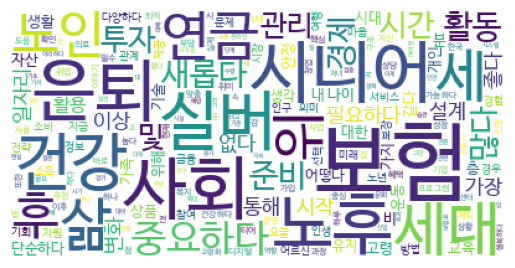

In [35]:

from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

words =[]
for i in df['token']:
    for w in i:
        words.append(w)
# print(words)
# Set font path for Korean characters
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # Adjust if necessary

count = Counter(words)
del count['이다']
del count['아니다']
# del count['않다']
# del count['그렇다']
# del count['되다']
del count['있다']
# del count['없다']
# del count['싶다']
# del count['좋다']
# del count['보다']
# del count['들다']
# del count['가다']
# del count['분']
# del count['시']
wc = WordCloud(font_path=font_path, background_color='white')
wc  = wc.generate_from_frequencies(count)
wc = wc.to_array()
plt.imshow(wc)
plt.axis('off')